# Predicting Wine Quality from Chemical Properties
**Authors**: Justin Kim, Aryan Arora, Shuri Yamamoto, Erhan Asad Javed

<br>

## Import & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

<br>

## Summary

This study explored the physicochemical characteristics of white wines and their relationship with quality ratings using exploratory data analysis and machine learning. The analysis showed that most wines fall within mid-range quality scores, with relatively few very low or very high ratings. Several chemical variables exhibit skewed distributions and occasional extreme values, while correlations suggest that wine quality is influenced by multiple factors rather than a single dominant variable. A random forest model was used to predict wine quality, achieving moderate accuracy but showing lower performance on minority classes due to class imbalance. These findings highlight the complexity of predicting wine quality and suggest that future work could improve results by addressing class imbalance and exploring more advanced models.

<br>

## Introduction

Wine is one of the most widely consumed beverages in the world, valued for its taste, cultural significance, and sensory qualities. Determining wine quality, even for expert tasters, can be challenging. Determining wine quality, even for expert tasters, can be challenging because sensory evaluation is inherently subjective and influenced by multiple factors (Jackson, 2014). Vinho verde wine is produced in the Minho region of northern Portugal and is known for its light and fresh characteristics. In this project, we focus on white vinho verde wine and investigate whether its physicochemical properties can be used to predict wine quality. To answer this question, we use a dataset from the UC Irvine Machine Learning Repository (Cortez et al., 2009) and apply predictive modeling techniques to explore relationships between chemical measurements and sensory quality scores.

### Dataset Description

The [Wine Quality dataset](https://archive-beta.ics.uci.edu/dataset/186/wine+quality) contains physicochemical measurements of Portuguese *Vinho Verde* wines. Each observation corresponds to a wine sample that was evaluated using laboratory tests and sensory analysis by wine experts.

The dataset includes 11 physicochemical input variables (e.g., acidity, pH, alcohol content) and 1 target variable representing wine quality. Wine quality scores were assigned as the median of at least three expert evaluations, with ratings ranging from 0 (very bad) to 10 (excellent).

There are two datasets exist in the Wine Quality dataset collection:
- Red wine: 1,599 observations  
- White wine: 4,898 observations  

For this analysis, we only use the white wine dataset as it contains the most number of samples.
<br>

#### Table 1: Feature Description

| Feature Name | Role | Type | Units | Description | Missing Values |
|-----|-----|-----|-----|-----|-----|
| fixed_acidity | Feature | Continuous | g/dm³ | Fixed acids (primarily tartaric acid) that do not evaporate easily. | No |
| volatile_acidity | Feature | Continuous | g/dm³ | Amount of acetic acid in wine; high levels can lead to an unpleasant vinegar taste. | No |
| citric_acid | Feature | Continuous | g/dm³ | Citric acid content, which can add freshness and flavor to wine. | No |
| residual_sugar | Feature | Continuous | g/dm³ | Amount of sugar remaining after fermentation stops. | No |
| chlorides | Feature | Continuous | g/dm³ | Salt content in the wine. | No |
| free_sulfur_dioxide | Feature | Continuous | mg/dm³ | Free form of sulfur dioxide that prevents microbial growth and oxidation. | No |
| total_sulfur_dioxide | Feature | Continuous | mg/dm³ | Total amount of sulfur dioxide (free + bound forms). | No |
| density | Feature | Continuous | g/cm³ | Density of the wine, influenced by alcohol and sugar content. | No |
| pH | Feature | Continuous | – | Acidity level of the wine; lower values indicate higher acidity. | No |
| sulphates | Feature | Continuous | g/dm³ | Potassium sulphate concentration, contributing to sulfur dioxide levels and preservation. | No |
| alcohol | Feature | Continuous | % (vol) | Alcohol content of the wine. | No |
| quality | Target | Integer | Score (0–10) | Wine quality score based on expert sensory evaluation. | No |

<br>
Table 1 shows that all features are numerical and there are no missing values in any feature.

<br>

## Methods 

### Dataset & Data Cleaning

The Wine Quality dataset is retrieved directly from the **UCI Machine Learning Repository** using the `ucimlrepo` library. The dataset is returned with the features (input variables) and the target variable (wine quality score) stored separately. 

To recreate the original dataset structure, we combine the features and target into a single DataFrame using `pd.concat()`. This produces a table where each row represents a wine sample and each column represents a physicochemical property or the quality score. However, this results in a DataFrame that contains both red and white wine data. Since we only aim to use white wine data, we clean the data by dropping the first 1599 samples, which correspond to red wine data, leaving only the 4898 white wine samples.

### EDA

Since EDA is generally performed after splitting the data, we first split the dataset into training and test sets, and then perform EDA using the training set. The dataset is initially split with a 70/30 ratio, and train set is further split into train and validation sets. Consequently, train set contains 2708 samples, validation set contains 720 samples, and test set contains 1470 samples. Figure 1 also visualizes the proportion of each dataset.

We examine the basic structure of the dataset by checking its shape, column names, data types, missing values, and statistical summary of each feature using the following functions:
- `df.shape` shows the number of rows and columns in the dataset.
- `df.columns` lists all variable names.
- `df.info()` provides the data type of each column and a summary of non-null values.
- `df.isnull().sum()` counts the number of missing values in each column.
- `df.describe()` provides summary statistics such as mean, standard deviation, and range for numerical variables.

We visualize the distribution of the target variable `quality` using a bar chart. The values are counted using `value_counts()` and sorted by quality score to show how many wines fall into each rating category. This helps us understand how wine quality scores are distributed across the dataset.

We generate histograms for each feature in the dataset using `df.hist()`. This allows us to visualize the distribution of values for each variable and observe patterns such as skewness, spread, and potential outliers across the physicochemical properties of the wines.

Lastly, we compute the correlation matrix using `df.corr()` to measure the linear relationships between all numerical variables in the dataset. The matrix is then visualized using `plt.imshow()`, where each cell represents the correlation between two variables.

### Prediction

To model wine quality, we require a method that can capture complex and potentially non-linear relationships between physicochemical features such as acidity, sugar content, and alcohol level. Preliminary exploration suggests that these variables may interact in ways that are not well represented by simple linear models. Additionally, the dataset contains multiple continuous predictors with possible correlations and varying scales, making model flexibility important. For this reason, we turn to the Random Forest model, an ensemble learning method that builds multiple decision trees and aggregates their predictions. Random Forest is well-suited for this task because it can handle non-linear patterns, is robust to overfitting through averaging, and provides insight into feature importance, allowing us to better understand which factors most strongly influence wine quality.

Since the random forest classifier is scale-invariant, we do not scale the data before training.

Grid search is used to explore various combinations of hyperparameters, and the best performing model with 20 `max_depth` and 100 `n_estimators` is achieved. 

The best model is evaluated using a classification report, which shows that the test accuracy, precison, recall, and F1-score. Figure 5 visualizes the confusion matrix on the test data to further examine its classification performance across different target classes.

<br>

## Results

#### Loading the Dataset & Data Wrangling

In [2]:
# Fetch dataset
wine_quality = fetch_ucirepo(id=186)

# Features and target
X = wine_quality.data.features
y = wine_quality.data.targets

# Concat features and target
df = pd.concat([X, y], axis=1)

# Drop white wine samples
df = df.iloc[1599:]

<br>

### Exploratory Data Analysis

#### Data Splitting

In [3]:
# split target with other features
X = df.drop(columns=['quality'])
y = df['quality']

# define train, validation, and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=123)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.21, shuffle=True, random_state=123)

<br>

#### Figure 1: Data Split Proportion

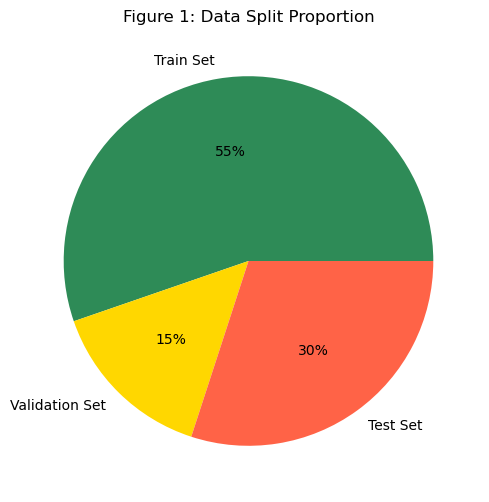

Train set length: 2708 | Validation set length: 720 | Test set length: 1470



In [4]:
# compute size for each dataset
data_size = len(df)
train_set_size = len(X_train) / data_size
valid_set_size = len(X_valid) / data_size
test_set_size = len(X_test) / data_size

# plot pie chart
plt.figure(figsize=(6, 6))
pie_colors = ['seagreen', 'gold', 'tomato']

plt.pie(
    [train_set_size, valid_set_size, test_set_size],
    labels=['Train Set', 'Validation Set', 'Test Set'],
    colors=pie_colors,
    autopct='%1.0f%%'
)

plt.title('Figure 1: Data Split Proportion')
plt.show()

print(f"Train set length: {len(X_train)} | Validation set length: {len(X_valid)} | Test set length: {len(X_test)}\n")

<br>

#### Inspecting the dataset structure


In [5]:
print("Shape of dataset:", X_train.shape)
print(f"\nColumn names:{list(X_train.columns)}")

Shape of dataset: (2708, 11)

Column names:['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [6]:
print("\nData types and info:")
X_train.info()


Data types and info:
<class 'pandas.DataFrame'>
Index: 2708 entries, 5497 to 4053
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         2708 non-null   float64
 1   volatile_acidity      2708 non-null   float64
 2   citric_acid           2708 non-null   float64
 3   residual_sugar        2708 non-null   float64
 4   chlorides             2708 non-null   float64
 5   free_sulfur_dioxide   2708 non-null   float64
 6   total_sulfur_dioxide  2708 non-null   float64
 7   density               2708 non-null   float64
 8   pH                    2708 non-null   float64
 9   sulphates             2708 non-null   float64
 10  alcohol               2708 non-null   float64
dtypes: float64(11)
memory usage: 253.9 KB


In [7]:
print("Missing values per column:")
X_train.isnull().sum()

Missing values per column:


fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

In [8]:
print("Summary statistics:")
X_train.describe()

Summary statistics:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,2708.000000,2708.000000,2708.000000,2708.000000,2708.000000,2708.000000,2708.000000,2708.000000,2708.000000,2708.000000,2708.000000
mean,6.846270,0.280835,0.335454,6.462832,0.046059,35.533789,139.034712,0.994057,3.184487,0.491562,10.493405
std,0.828504,0.101603,0.120338,5.172827,0.022880,17.545857,42.560629,0.003072,0.149090,0.116900,1.228132
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,18.000000,0.987110,2.720000,0.230000,8.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,24.000000,110.000000,0.991720,3.080000,0.410000,9.400000
50%,6.800000,0.260000,0.320000,5.300000,0.043000,34.000000,134.000000,0.993700,3.170000,0.480000,10.300000
75%,7.300000,0.330000,0.390000,9.900000,0.050000,45.000000,168.000000,0.996130,3.280000,0.550000,11.400000
max,14.200000,1.005000,1.000000,65.800000,0.346000,289.000000,440.000000,1.038980,3.770000,1.080000,14.200000


<br>

#### Figure 2: Distribution of Wine Quality

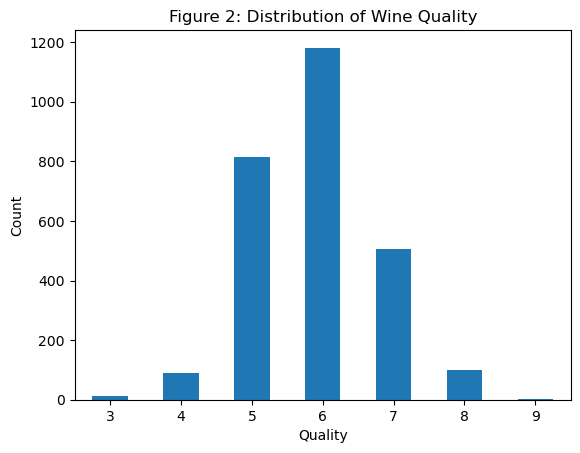

In [13]:
plt.figure()
y_train.value_counts().sort_index().plot(kind="bar")
plt.title("Figure 2: Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Figure 2 shows that the distribution of wine quality scores is concentrated around the middle values. Most wines are rated 5, 6, or 7, with quality 6 being the most frequent. Very few wines receive extreme ratings such as 3 or 9, indicating that the dataset contains mostly average-quality wines and relatively few very poor or excellent samples. This indicates a significant class imbalance. Moreover, although the UCI Machine Learning Repository lists the wine quality feature ranging from 0 to 10, there are no samples for 0, 1, 2 and 10, and thus the model will never encounter these classes during training. These issues raise concerns that model may perform poorly on the minority classes, which correspond to extremely low or high quality wines.

<br>

#### Figure 3: Feature Distributions

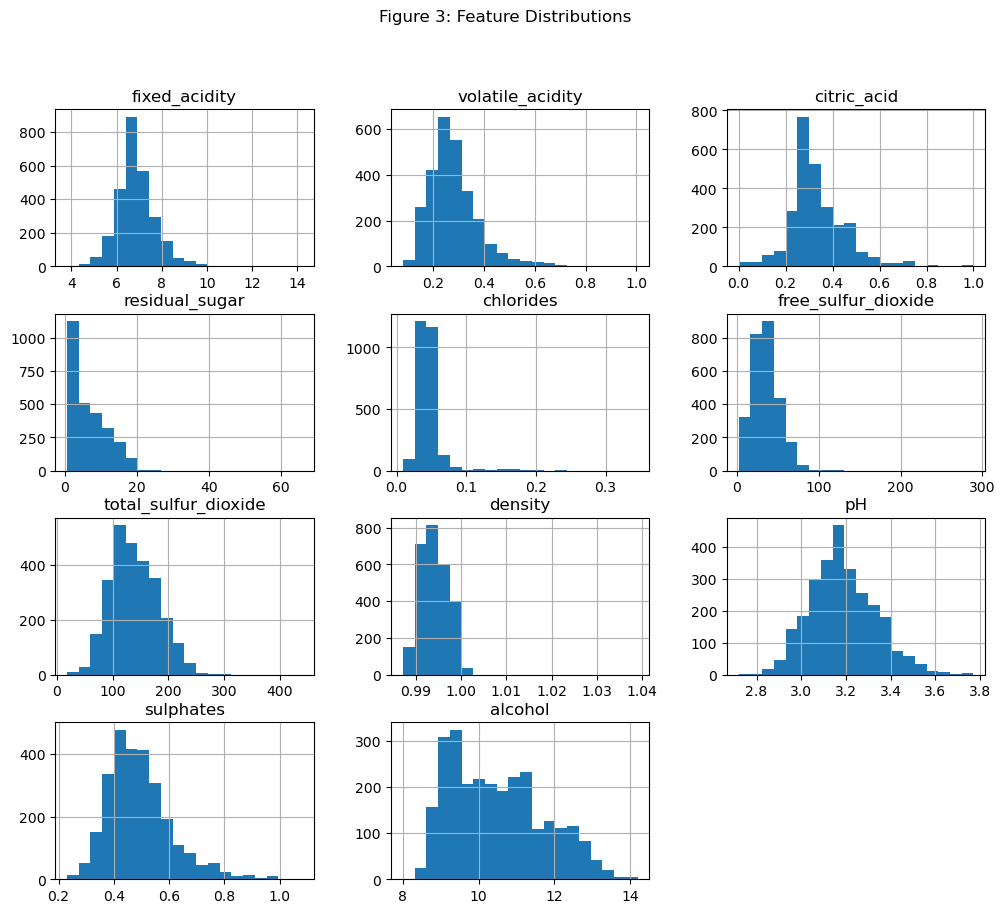

In [10]:
X_train.hist(bins=20, figsize=(12,10))
plt.suptitle("Figure 3: Feature Distributions")
plt.show()

Figure 3 shows that most physicochemical variables fall within fairly narrow ranges. For example, pH values are centered around 3.1 with a small spread, and density is close to 0.995 for most wines. Alcohol content ranges roughly from 9% to 14%, with an average around 10.5%. In contrast, residual sugar varies much more widely, ranging from under 1 to over 60, indicating some extreme observations.

The figure also suggests that several variables are right-skewed, meaning most wines have lower values with a few much larger observations. This pattern is especially noticeable for chlorides, residual sugar, sulphates, and fixed acidity. Total sulfur dioxide appears roughly more evenly distributed around the average.

<br>

#### Figure 4: Correlation Matrix

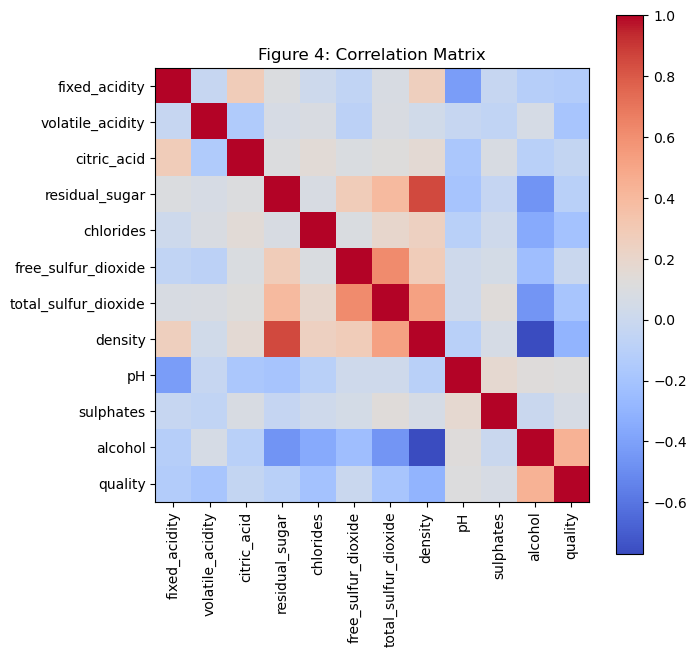

In [11]:
corr = pd.concat([X_train, y_train], axis=1).corr()

plt.figure(figsize=(7,7))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Figure 4: Correlation Matrix")
plt.show()

Figure 4 shows the strength and direction of linear relationships between the variables. Overall, most physicochemical features have relatively weak correlations with wine quality, suggesting that quality is influenced by multiple factors rather than a single dominant variable. Alcohol content tends to have a positive relationship with quality, while variables such as volatile acidity and density show negative relationships. Many of the input variables also show moderate correlations with each other, indicating that some chemical properties of the wine are related.

<br>

### Prediction

#### Model Construction

In [12]:
# define random forest model
rf_model = RandomForestClassifier(random_state=123)

<br>

#### Grid Search

In [13]:
# define param grid for gird search
param_grid = {
    'n_estimators': [10, 50, 100, 200, 400],
    'max_depth': [2, 10, 20, 30, 40, 50]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=2, return_train_score=True, n_jobs=-1)

# fit grid search
grid_search.fit(X_train, y_train)

# print best params
print(f'Best parameters found from grid search: {grid_search.best_params_}')

Best parameters found from grid search: {'max_depth': 20, 'n_estimators': 100}


<br>

#### Model Evaluation on Test Data

In [14]:
# retrieve best performing model
best_model = grid_search.best_estimator_

pred = best_model.predict(X_test)

<br>

#### Figure 5: Test Data Confusion Matrix

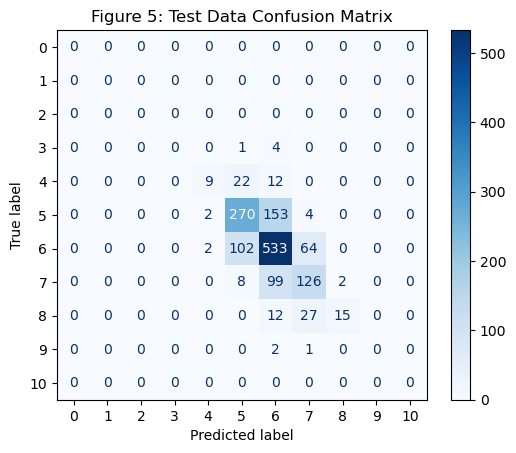

In [15]:
labels = [i for i in range(11)]

cm = confusion_matrix(y_test, pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Figure 5: Test Data Confusion Matrix")
plt.show()

In [16]:
print(classification_report(pred, y_test, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.21      0.69      0.32        13
           5       0.63      0.67      0.65       403
           6       0.76      0.65      0.70       815
           7       0.54      0.57      0.55       222
           8       0.28      0.88      0.42        17
           9       0.00      0.00      0.00         0

    accuracy                           0.65      1470
   macro avg       0.34      0.50      0.38      1470
weighted avg       0.68      0.65      0.66      1470



We evaluate model performance using accuracy, precision, recall, and F1-score. While accuracy measures overall correctness, precision shows how reliable positive predictions are, recall measures how well actual positives are identified, and F1-score balances precision and recall, making it especially useful under class imbalance. The definitions are as follows:
- Accuracy:
    - Formula: $\frac{TP + TN}{TP + TN + FP + FN}$
    - Definition: proportion of correct classifications out all predictions.
- Precision:
    - Formula: $\frac{TP}{TP+FP}$
    - Definition: proportion of correct positive predictions out all positive predictions. It tells you how much of the model's positive predictions is correct.
- Recall:
    - Formula: $\frac{TP}{TP+FN}$
    - Definition: proportion of correct positive predictions out of actual positive sampples. It tells you how many actual positive samples the model can capture.
- F1-score:
    - Formula: $2 \times \frac{Precision \times Recall}{Precision + Recall}$
    - Definition: F1-score is a harmonic mean of precision and recall. It tells you the model's classification performance by addressing both precision and recall. To achieve a high F1-score, both precision and recall should be high enough.


<br>
As mentioned earlier, since there is a significant class imbalance, accuracy might not be a reliable metirc to examine test performance. Here, macro test precision of 34% and recall of 50% indicates a significant error in model's classification performance. 

Although, recall is relatively similar across classes, there is a distinct gap in precision between the minority classes and the dominant classes. Especially, the minority classes, wine quality 4 and 8, have precision of 21% and 28% while the mose frequent class, 6, has precision of 76%. This implies that the minority classes are more likely to experience false positives compared to dominant classes. We can also identify this biased behavior in Figure 5. Figure 5 shows that positive predictions for the dominant classes are more likely to include true positives while the minority classes have more false positives than true positives. Furthermore, these two minority classes have the lowest F1-scores, suggesting that the model's overall peformance is biased in favor of the dominant classes.

However, even the dominant classes, 5, 6, and 7, exhibit a moderate to significant degree of error in F1-score, suggesting that the model's overall performance in predicting white wine quality is suboptimal. 

<br>

## Discussion

The exploratory data analysis suggests that most wines in the dataset fall into average quality categories, with ratings concentrated around the middle of the scale. This indicates that class imbalance in which extremely high or low quality wines are relatively uncommon. The distributions of many physicochemical variables show that most measurements lie within typical ranges, although some variables such as residual sugar and chlorides exhibit wider spreads and occasional extreme values. Several variables also appear right-skewed, meaning most wines have relatively small values with a few larger observations. This pattern suggests that certain chemical properties occur at low levels for most wines but can occasionally be much higher. The correlation analysis further indicates that no single variable strongly determines wine quality. Instead, wine quality appears to be influenced by a combination of multiple chemical characteristics, with some variables showing modest positive or negative relationships with the quality score.

The random forest classifier with `max_depth` of 20 and `n_estimator` of 100 is achieved through grid search. Our model achieves a macro test accuracy of 65%, a precision of 34%, a recall of 50%, and an F1-score of 38%, showing a sign of underperformance in predicting white wine quality. Since our task is more complex than binary classification, this result is expected, as the random forest model is not the most powerful model for this task compared to other approaches such as MLPs. Similar studies have found that machine learning can identify relationships between chemical composition and wine quality, but prediction accuracy often depends on model choice and feature representation (Rodriguez-Galiano et al., 2015; Sagi & Rokach, 2018). Moreover, the model exhibits a biased performance favoring the dominant classes. This behavior is expected as currently no method is applied to handle class imbalance. Hence, for future work, we suggest to handle class imbalance with up/oversampling or reweighing to improve fairness and perfrmance across all classes.

Future work could explore methods to address class imbalance, such as oversampling or class weighting, to improve prediction across all quality levels. In addition, testing more advanced models such as gradient boosting or neural networks may help capture more complex relationships between variables. Further research could also examine whether additional information, such as sensory or production data, improves predictive performance.

<br>

## References

[1] Jackson, R. S. (2020). Wine science: principles and applications. Academic press.

[2] Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. Decision Support Systems.

[3] Rodriguez-Galiano, V., Sanchez-Castillo, M., Chica-Olmo, M., & Chica-Rivas, M. J. O. G. R. (2015). Machine learning predictive models for mineral prospectivity: An evaluation of neural networks, random forest, regression trees and support vector machines. Ore geology reviews, 71, 804-818.

[4] Sagi, O., & Rokach, L. (2018). Ensemble learning: A survey. Wiley interdisciplinary reviews: data mining and knowledge discovery, 8(4), e1249.